In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from terratorch import FULL_MODEL_REGISTRY
import torch
from torch.utils.data import DataLoader

from src.terramesh import build_terramesh_dataset, Transpose, MultimodalTransforms
from src.plotting_utils import plot_modality

# Select device
if torch.cuda.is_available():
    device = 'cuda'    
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Using {device}")

Using cpu


/dss/dsshome1/08/di35pap/micromamba/envs/terramind-geogen/lib/python3.11/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
# Define all image modalities
modalities = ["S2L2A", "S2L1C", "S2RGB", "S1GRD", "S1RTC", "DEM", "NDVI", "LULC"]
LOCAL_TERRAMESH_PATH = "/dss/dsstbyfs02/pn49cu/pn49cu-dss-0020/terramesh_val/data/TerraMesh/"

# Define multimodal transform function that converts the data into the expected shape from albumentations 
val_transform = MultimodalTransforms(
    transforms=A.Compose([  # We use albumentations because of the shared transform between image modalities
        Transpose([1, 2, 0]),  # Convert data to channel last (expected shape from albumentations)
        A.CenterCrop(224, 224),  # Use center crop in val split
        # A.RandomCrop(224, 224),  # Use random crop in train split
        # A.D4(),  # Optionally, use random flipping and rotation for the train split
        ToTensorV2(),  # Convert to tensor and back to channel first
    ],
        is_check_shapes=False,  # Not needed because of aligned data in TerraMesh
        additional_targets={m: "image" for m in modalities},  # Only image keys
    ),
    non_image_modalities=["__key__", "__url__", "center_lon", "center_lat", "cloud_mask"] + ["time_" + m for m in modalities]
)

dataset = build_terramesh_dataset(
    path=LOCAL_TERRAMESH_PATH,
    modalities=modalities,
    split="val",
    shuffle=False,
    seed=42,
    transform=val_transform,
    batch_size=1,
    return_metadata=True,
)

# Set batch size to None because batching is handled by WebDataset.
dataloader = DataLoader(dataset, batch_size=None, num_workers=32, persistent_workers=True, prefetch_factor=1)

In [3]:
# The following code works selecting one of the following modalities as input modality
# And one or more of the other modalities as out_modalities
in_modality = "S2L2A"
out_modalities = ["S1RTC", "S2L1C", "LULC", "DEM", "NDVI", "Coordinates"]

# Iterate over the dataloader
for i, batch in enumerate(dataloader):
    if i==0:  # The first patch is less intersting, so skip that as example
        continue
    #print("Batch keys:", list(batch.keys()))
    # Batch keys: ["__key__", "__url__", "S2L2A", "S2L1C", "S2RGB", "S1RTC", "DEM", "NDVI", "LULC"]
    # Because S1RTC and S1GRD are not present for all samples, each batch only includes one S1 version.

    batch["Coordinates"] = torch.cat([batch["center_lon"], batch["center_lat"]], dim=0).unsqueeze(0)

    # Preprocess input data to the model: expects float type
    in_data = batch[in_modality].float()

    # Run generation (this can take a while without a GPU, consider reducing timesteps for faster inference)    
    outputs = {}
    for output_modality in out_modalities:
        print(f'Processing {output_modality}')
        
        # Init model
        model = FULL_MODEL_REGISTRY.build(
            'terramind_v1_base_generate',
            modalities=[in_modality],
            output_modalities=[output_modality],
            pretrained=True,
            standardize=True,
        )
        _ = model.to(device)
        
        input = in_data.clone().to(device)
        with torch.no_grad():
            generated = model(input, verbose=True, timesteps=10)
        outputs[output_modality] = generated

    print(outputs)
    break  # Visualize one sample only

Processing S1RTC


INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-Tokenizer-S1RTC/resolve/main/TerraMind_Tokenizer_S1RTC.pt "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"
100%|██████████| 10/10 [00:21<00:00,  2.19s/it]


Processing S2L1C


INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-Tokenizer-S2L2A/resolve/main/TerraMind_Tokenizer_S2L2A.pt "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"
100%|██████████| 10/10 [00:22<00:00,  2.29s/it]


Processing LULC


...

Processing NDVI


INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-Tokenizer-NDVI/resolve/main/TerraMind_Tokenizer_NDVI.pt "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"
100%|██████████| 10/10 [00:21<00:00,  2.15s/it]


Processing Coordinates


INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-Tokenizer-Coords/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ibm-esa-geospatial/TerraMind-1.0-Tokenizer-Coords/b6664f494c2d79f9205525d2f3445413813214de/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"


{'S1RTC': {'S1RTC': tensor([[[[ -8.7141,  -9.0991,  -8.9718,  ...,  -9.3753,  -9.1087, -10.1527],
          [ -9.1624,  -9.0973,  -8.7528,  ...,  -8.9632,  -7.9297,  -8.5346],
          [ -8.9308,  -8.6541,  -8.6893,  ...,  -8.5207,  -6.5419,  -6.7547],
          ...,
          [ -8.1598,  -7.7420,  -7.4462,  ...,  -9.5186, -10.1547,  -9.6440],
          [ -9.7064,  -9.1350,  -7.5302,  ...,  -8.4233,  -8.8639,  -8.4564],
          [-10.4966, -10.4253,  -9.5653,  ...,  -7.5407,  -7.4958,  -7.5823]],

         [[-15.2919, -14.8972, -14.6040,  ..., -15.8934, -17.2517, -17.8848],
          [-15.6645, -15.0445, -14.3761,  ..., -15.4929, -16.6631, -16.8600],
          [-16.6111, -15.9351, -14.9830,  ..., -15.5197, -16.1795, -16.5924],
          ...,
          [-14.9991, -15.9131, -17.2844,  ..., -19.9400, -20.3605, -18.2360],
          [-13.1286, -14.3956, -16.2233,  ..., -17.5890, -18.6201, -17.0207],
          [-12.8700, -13.6094, -14.9227,  ..., -14.8888, -15.7737, -15.3288]]]])}, 'S2L1C'

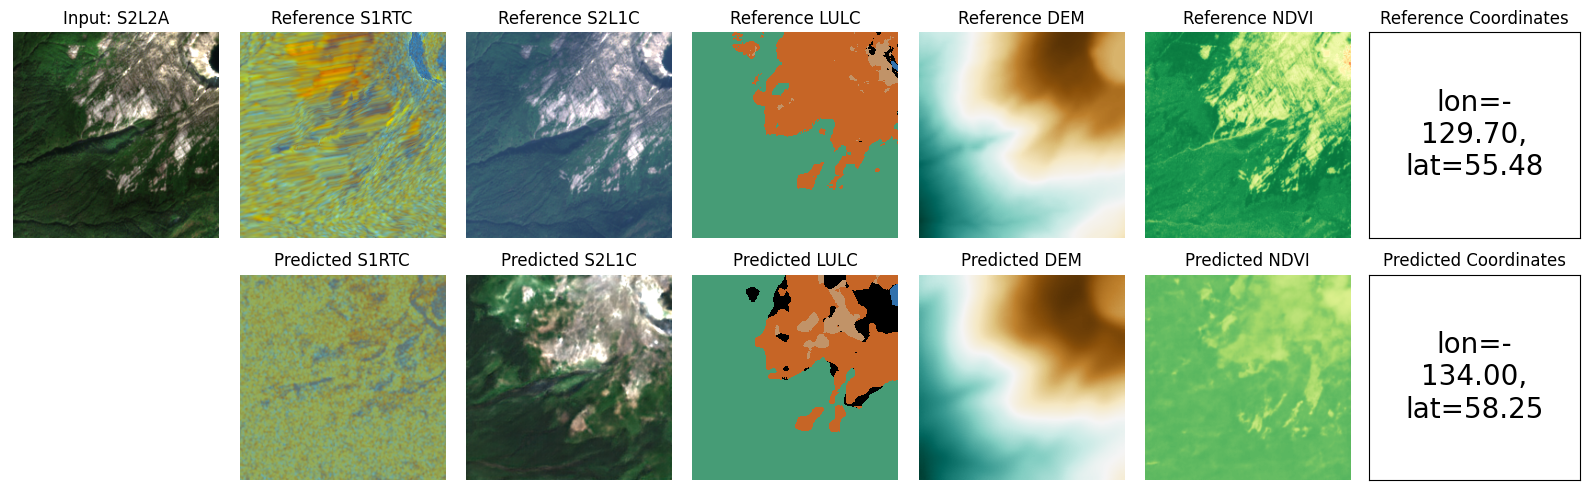

In [4]:
# Plot any-to-any generations
fig, axes = plt.subplots(nrows=2, ncols=len(out_modalities) + 1, figsize=[16, 5])

plot_modality(in_modality, batch[in_modality], ax=axes[0][0])
axes[0][0].set_title(f"Input: {in_modality}")
axes[0][0].axis('off')
axes[1][0].axis('off')

for i, out_modality in enumerate(out_modalities):
    axes[0, i+1].set_title(f"Reference {out_modality}")
    plot_modality(out_modality, batch[out_modality], ax=axes[0][i+1])
    axes[1, i+1].set_title(f"Predicted {out_modality}")
    plot_modality(out_modality, outputs[out_modality][out_modality], ax=axes[1][i+1])

plt.tight_layout()
plt.savefig(f"../figures/any-to-any_input-{in_modality}.png", dpi=300)
plt.show()